#1 Identifying features with lowest and highest dicriminative power.

In [6]:
from scipy.io.arff import loadarff
import pandas as pd
import sklearn
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np


data = loadarff('column_diagnosis.arff')
df = pd.DataFrame(data[0])
df['class'] = df['class'].str.decode('utf-8')

X = df.drop('class', axis=1)
y = df['class']

score, p_value = f_classif(X, y)

score_to_feature = {}

for i in range(len(score)):
    score_to_feature[X.columns.values[i]] = score[i]

lowest = min(score_to_feature, key=score_to_feature.get)
highest = max(score_to_feature, key=score_to_feature.get)

print(f"Feature with lowest discriminative power - '{lowest}'. \nFeature with highest discriminative power - '{highest}'.")

Feature with lowest discriminative power - 'pelvic_radius'. 
Feature with highest discriminative power - 'degree_spondylolisthesis'.


#Plot class-conditional probability density functions of the features with the highest and the lowest discriminative power

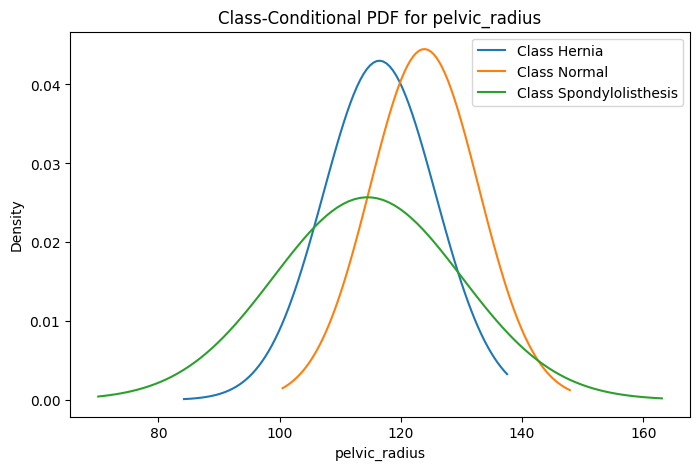

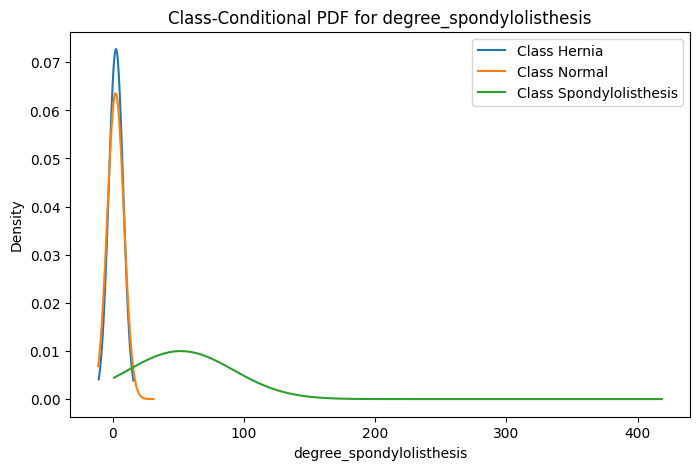

array(['Hernia', 'Normal', 'Spondylolisthesis'], dtype=object)

In [7]:
def plot_class_conditional_pdf(variable_values, class_labels, variable_name):
    plt.figure(figsize=(8, 5))

    for class_label in np.unique(class_labels):
        class_variable_values = variable_values[class_labels == class_label]
        mean, std = norm.fit(class_variable_values)
        xmin, xmax = min(class_variable_values), max(class_variable_values)
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean, std)
        plt.plot(x, p, label=f'Class {class_label}')

    plt.title(f'Class-Conditional PDF for {variable_name}')
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

lowest_values = X[lowest].values
highest_values = X[highest].values

plot_class_conditional_pdf(lowest_values, y, lowest)
plot_class_conditional_pdf(highest_values, y, highest)
np.unique(y)

#2 Training decision tree model with different depth limits

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [9]:
seed = 0

depth_limits = [1, 2, 3, 4, 5, 6, 8, 10]

train_accuracies = []
test_accuracies = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

for depth_limit in depth_limits:

    dt_classifier = DecisionTreeClassifier(max_depth=depth_limit, random_state=seed)
    dt_classifier.fit(X_train, y_train)

    train_accuracy = dt_classifier.score(X_train, y_train)
    test_accuracy = dt_classifier.score(X_test, y_test)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)


#Plotting the accuracies of models with differen depth limits

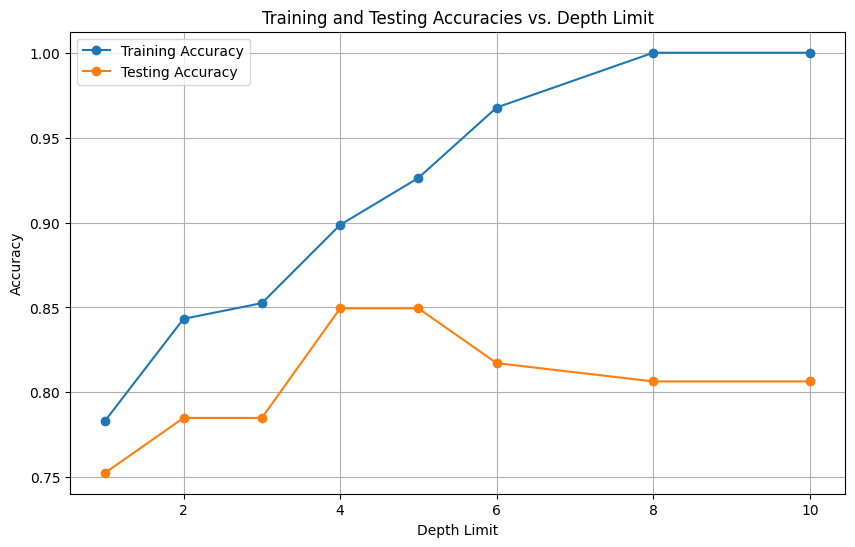

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(depth_limits, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(depth_limits, test_accuracies, marker='o', label='Testing Accuracy')
plt.xlabel('Depth Limit')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracies vs. Depth Limit')
plt.legend()
plt.grid(True)
plt.show()

#Interpretation of results:

What we can see on the plot is accuracies on test dataset starts trending down when the depth limit is more then 5, while the accuracies on train dataset is always growing. This means that, when our model has depth limit more than 5, it starts overfitting to our training dataset, remembering the shape of each case instead of generalizing for all the population (that includes cases that are not in training dataset). On the other hand when the depth limit of our model is less than 4 accuracies are not that that great neither on the training or test dataset, this is because our model is underfitting on the data, it means that it is generalizing too much, so it's prediction power is lower.

# 4 BUILDING A MODEL TRAINED WITH ALL DATA SAMPLES

In [11]:
classifier_all = DecisionTreeClassifier(random_state=0, min_samples_leaf=20)

# Train the decision tree on all dataset
classifier_all.fit(X, y)

DecisionTreeClassifier(min_samples_leaf=20, random_state=0)

# 4.1 PLOT THE DECISION TREE


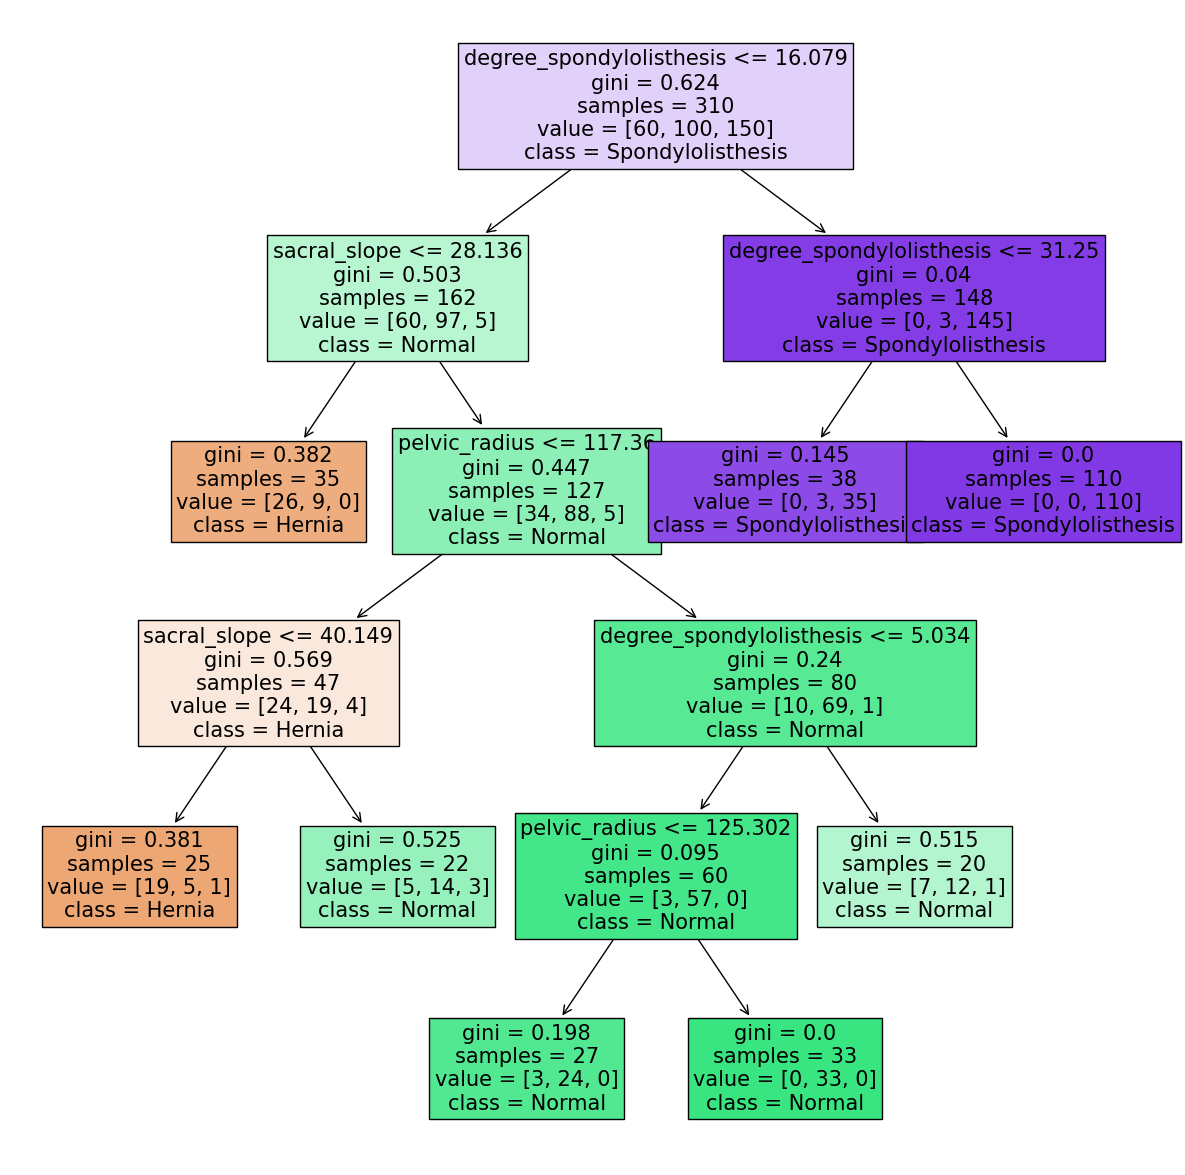

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 15))
plot_tree(classifier_all, filled=True, feature_names=X.columns, class_names=classifier_all.classes_, fontsize = 15)
plt.show()

#4.2 Characterizing a hernia condition by identifying the hernia-conditional associations

* Hernia condition :           
  A person will be classified with a hernia condition if :    
   * This person has ***degree spondylolisthesis*** less than 16.079 and ***sacral slope*** less than 28.136.

   OR
   * This person has ***degree spondylolisthesis*** less than 16.079, ***sacral slope*** bigger than 28.136, ***pelvic radius*** less than 117.36 and ***sacral slope*** less than 40.149.

* Spondylolisthesis condition :            
  A person will be classified with spondylolisthesis condition if this person has ***degree spondylolisthesis*** bigger than 16.079.

* Normal condition :      
 A person will be classified as normal if :
 * This person has ***degree spondylolisthesis*** less than 16.079, ***sacral slope*** bigger than 28.136, ***pelvic radius*** less than 117.36 and ***sacral slope*** bigger than 40.149.

   OR
 * This person has ***degree spondylolisthesis*** less than 16.079, ***sacral slope*** bigger than 28.136, ***pelvic radius*** bigger than 117.36.